# 4 Model Evaluation

This notebook loads our own finetuned Whisper model and then evaluates it.

In [ ]:
import sys, os
from pathlib import Path
import torch

notebook_dir = Path.cwd()
whisper_dir = notebook_dir.parent
sys.path.append(str(whisper_dir))

from whisper_asr import transcribe_whisper, compute_idiom_results, print_evaluation_results, plot_wer_violin, load_all_data, apply_causal_attention_mask
from whisper_asr.utils import get_best_gpu, normalize_romansh_text
from whisper_asr.constants import MODELS_ROOT
from transformers import WhisperProcessor, WhisperForConditionalGeneration
from jiwer import wer, cer
import random

os.environ["TOKENIZERS_PARALLELISM"] = "false"

MODEL_PATH = MODELS_ROOT / "whisper-medium-rm"
DEVICE = torch.device(f"cuda:{get_best_gpu()}" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 8

print(f"Using device: {DEVICE}")

Selected GPU 5 with 24088 MiB free memory
Using device: cuda:5


Load model and processor

In [ ]:
processor = WhisperProcessor.from_pretrained(MODEL_PATH)
model = WhisperForConditionalGeneration.from_pretrained(MODEL_PATH).to(DEVICE)

# attention masking
# apply_causal_attention_mask(model)

print("Model loaded.")

Loading weights: 100%|██████████| 947/947 [00:01<00:00, 581.99it/s]


Model loaded.


Load test data

In [7]:
test_df = load_all_data("test")
audio_paths = test_df["audio_path"]
references = test_df["sentence"]
idioms = test_df["idiom"]

Generate transcriptions for test data

In [8]:
test_df['transcriptions'] = transcribe_whisper(model, processor, audio_paths, batch_size=BATCH_SIZE, device=DEVICE)

Transcribing (Whisper):   0%|          | 0/79 [00:00<?, ?it/s]

Transcribing (Whisper): 100%|██████████| 79/79 [04:01<00:00,  3.05s/it]


Compute and display the results

In [7]:
test_df['transcriptions'] = test_df['transcriptions'].apply(normalize_romansh_text)
transcriptions = test_df['transcriptions']
summary_df, overall_wer, overall_cer, valid_pairs = compute_idiom_results(references, transcriptions, idioms)
print_evaluation_results(summary_df, overall_wer, overall_cer, len(audio_paths), len(valid_pairs))


OVERALL RESULTS
Total test samples: 631
Valid pairs: 631/631

Word Error Rate (WER): 0.1968 (19.68%)
Character Error Rate (CER): 0.0712 (7.12%)

PER IDIOM RESULTS

RG
  Samples: 81
  WER: 0.0718 (7.18%)
  CER: 0.0234 (2.34%)

PUTER
  Samples: 114
  WER: 0.1756 (17.56%)
  CER: 0.0533 (5.33%)

SURSILVAN
  Samples: 94
  WER: 0.2305 (23.05%)
  CER: 0.0775 (7.75%)

SURMIRAN
  Samples: 151
  WER: 0.2079 (20.79%)
  CER: 0.0708 (7.08%)

SUTSILVAN
  Samples: 94
  WER: 0.2413 (24.13%)
  CER: 0.0874 (8.74%)

VALLADER
  Samples: 97
  WER: 0.2446 (24.46%)
  CER: 0.1174 (11.74%)

SUMMARY TABLE
    idiom  samples      wer      cer
       RG       81 0.071849 0.023413
    Puter      114 0.175562 0.053299
Sursilvan       94 0.230510 0.077506
 Surmiran      151 0.207874 0.070836
Sutsilvan       94 0.241267 0.087445
 Vallader       97 0.244552 0.117403


/local/scratch/matuor/Romansh-ASR/whisper/whisper_asr/analysis.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/local/scratch/matuor/Romansh-ASR/whisper/whisper_asr/analysis.py:57: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


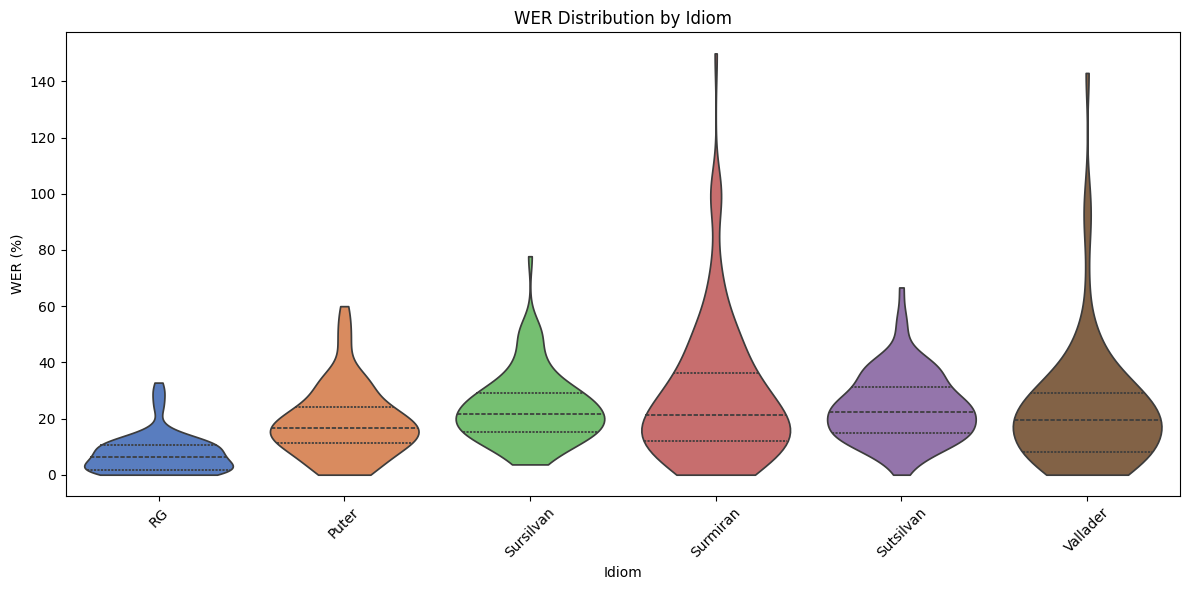

In [8]:
plot_wer_violin(references, transcriptions, idioms)

Random Samples

In [9]:
sample_indices = random.sample(range(len(valid_pairs)), min(5, len(valid_pairs)))

for i, idx in enumerate(sample_indices):
    print(f"--- Sample {i} ---")
    print(f"Idiom: {idioms[idx]}")
    print(f"Reference: {references[idx]}")
    print(f"Hypothesis: {transcriptions[idx]}")
    sample_wer, sample_cer = wer(references[idx], transcriptions[idx]), cer(references[idx], transcriptions[idx])
    print(f"Sample WER: {sample_wer:.4f}, Sample CER: {sample_cer:.4f}")
    print("-" * 40)

--- Sample 0 ---
Idiom: Sutsilvan
Reference: nus vagn prieu ampo uras anglesas qua a cuira aber vagn amprieu poc parque ca luvravan amadus vevan ear nigna peada ad anc da lugar dad ir a tut anzemel lu eassan vagnieu a kenia
Hypothesis: a nus vean prieu ampo uras anglesas qua a cuira aber vagnan prieu poc parque ca luvrava an domat uss vevan eni egna peda ad anc da lua gada dad ir a tut anzemel lu eassan vagnis a kenia
Sample WER: 0.4000, Sample CER: 0.1404
----------------------------------------
--- Sample 1 ---
Idiom: Surmiran
Reference: 30avel anniversari en eh
Hypothesis: 30 ava lanniversari en ah
Sample WER: 1.0000, Sample CER: 0.2083
----------------------------------------
--- Sample 2 ---
Idiom: Surmiran
Reference: schi franc scu tgi turna mintgonn la premaveira porta er igl postign igls chints da taglia cura tgi mamma veva propi schleta luna alloura savevans ossa en rivos igls chints da taglia en per deis vevla da morder povra mamma ella tgi saveva bagn avonda tgi chel pitsche